# Import Statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet

In [3]:

from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns


/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.linear_model import Lasso

from sklearn.metrics import accuracy_score


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
import tqdm as notebook_tqdm
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [7]:
from platform import python_version

print(python_version())


3.10.12


In [8]:
print(np.__version__)

1.26.3


# Define all functions

In [9]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}

# set parameter space for LASSO

elasticnet_space = {
    'alpha': Real(1e-3, 1.0, 'log-uniform'),
    'l1_ratio': Real(0.1, 0.99, 'uniform')
}

In [10]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [11]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

def bayesian_elasticnet_search(X, y, elasticnet_space):
    elasticnet = ElasticNet(max_iter=100000)
    elasticnet_bayes_search = BayesSearchCV(
        estimator=elasticnet,
        search_spaces=elasticnet_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=2,
        n_jobs=-1
)
    elasticnet_bayes_search.fit(X, y)
    
    print("Best ElasticNet hyperparameters:", elasticnet_bayes_search.best_params_)
    
    best_params = elasticnet_bayes_search.best_params_
    best_elasticnet = ElasticNet(**best_params)

    return best_elasticnet
    
#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [12]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [13]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [9]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [15]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [10]:
#Load file
tt_md = pd.read_pickle("../pickle_files/training_data_md.pkl")
tt_md.head()

FileNotFoundError: [Errno 2] No such file or directory: '../pickle_files/training_data_md.pkl'

In [18]:
tt_md.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251242 entries, Line to MD
dtypes: float64(5), int64(251236), object(1)
memory usage: 4.6+ GB


In [19]:
#Extract only SNPs for feature selection

In [20]:
feature= tt_md.iloc[:, 1:251229]
feature.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1019_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [21]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251228 entries, Chr1_15246 to Chr20_52267897
dtypes: int64(251228)
memory usage: 4.6+ GB


In [22]:
target = tt_md["MD"]
target.head()

new_line
s100_BeiJing_2013    155.0
s100_HeNan_2015      115.0
s1014_HeNan_2014     108.0
s1014_HeNan_2015     104.0
s1019_HeNan_2015     113.0
Name: MD, dtype: float64

In [23]:
cov = tt_md.iloc[:,-12:]
cov.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,
s100_BeiJing_2013,9.5000,6.26667,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,10.2133,4.00000,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,11.8200,7.78667,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,13.2800,6.94667,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,10.8400,7.34667,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [21]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [59]:
#X_train_subset = X_train.iloc[:, :1000]
#X_train_subset.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr1_4969562,Chr1_4982468,Chr1_4988225,Chr1_4990892,Chr1_5004708,Chr1_5007930,Chr1_5012238,Chr1_5022900,Chr1_5022975,Chr1_5023098
new_line,,,,,,,,,,,,,,,,,,,,,
s461_BeiJing_2013,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
s560_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
s130_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s2427_HeiLongJiang_2014,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,2,0,1,0
s789_BeiJing_2013,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
best_elasticnet = bayesian_elasticnet_search(X_train, y_train, elasticnet_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time= 7.5min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time= 9.8min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=12.1min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=12.3min
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  19.8s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  20.3s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  22.2s
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=32.5min
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  34.2s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; to

In [24]:
# Create a ElasticNet Regression model with the best parameters from bayes CV
#Best ElasticNet hyperparameters: OrderedDict([('alpha', 0.7352481813242628), ('l1_ratio', 0.7235530857130157)])
alpha = 0.7352  # Regularization strength (adjust from best_params)
l1_ratio = 0.7235
best_elasticnet_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

# Fit the model to the full training data
best_elasticnet_model.fit(feature, target)

ElasticNet(alpha=0.7352, l1_ratio=0.7235)

In [25]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['Chr1_15246' 'Chr1_17750' 'Chr1_23692' ... 'Chr20_52266575'
 'Chr20_52267177' 'Chr20_52267897']


In [26]:
# Using np.abs() to make coefficients positive.  
elasticnet_coef = np.abs(best_elasticnet_model.coef_)

In [27]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = elasticnet_coef != 0

In [28]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))


In [29]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [31]:
new_data = tt_md[selected_feature]
print(new_data.head())

                   Chr1_2475213  Chr1_2645491  Chr1_15775291  Chr1_16121722  \
new_line                                                                      
s100_BeiJing_2013             0             0              1              2   
s100_HeNan_2015               0             0              1              2   
s1014_HeNan_2014              2             2              0              0   
s1014_HeNan_2015              2             2              0              0   
s1019_HeNan_2015              0             0              0              0   

                   Chr1_50820261  Chr1_51525075  Chr1_53630801  Chr1_54026007  \
new_line                                                                        
s100_BeiJing_2013              1              0              0              2   
s100_HeNan_2015                1              0              0              2   
s1014_HeNan_2014               2              2              0              1   
s1014_HeNan_2015               2         

In [32]:
new_data.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_39258975,Chr20_39890366,Chr20_40195415,Chr20_40942681,Chr20_43468889,Chr20_43870603,Chr20_48582557,Chr20_50003028,Chr20_50084112,Chr20_51274009
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s100_HeNan_2015,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s1014_HeNan_2014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1014_HeNan_2015,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1019_HeNan_2015,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,2,2,0,2,2,0


In [33]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 336 entries, Chr1_2475213 to Chr20_51274009
dtypes: int64(336)
memory usage: 6.4+ MB


In [34]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,1,2,1,0,0,2,2,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,0,0,1,2,1,0,0,2,2,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,2,2,0,0,2,2,0,1,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,2,2,0,0,2,2,0,1,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,0,0,0,0,0,0,0,1,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [35]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 348 entries, Chr1_2475213 to MD
dtypes: float64(5), int64(343)
memory usage: 6.5+ MB


In [36]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,0,0,1,2,1,0,0,2,2,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,2,2,0,0,2,2,0,1,2,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,2,2,0,0,2,2,0,1,2,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,0,0,0,0,1,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [37]:
fs_data.to_pickle("fs_md_enet_training_data.pkl")

In [11]:
fs_data = pd.read_pickle("../pickle_files/fs_md_enet_training_data.pkl")

In [39]:
fs_data.to_csv("fs_md_enet_training_data.txt")

# All traits

In [12]:
X_all = fs_data.drop("MD", axis=1).values
y_all = fs_data["MD"].values

In [13]:
X_dupe = fs_data.drop("MD", axis=1)
X_dupe.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,0,0,1,2,1,0,0,2,2,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1
s1019,0,0,0,0,0,0,0,1,0,0,...,7.34667,61.0,4.60000,0,0,1,0,0,0,1


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [16]:
X_train.shape

(2205, 347)

In [45]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5946061254230032), ('colsample_bytree', 0.6505191154975687), ('gamma', 0.01507115700265043), ('learning_rate', 0.02487192942188578), ('max_delta_step', 20), ('max_depth', 31), ('min_child_weight', 9), ('n_estimators', 200), ('reg_alpha', 1.0), ('reg_lambda', 3.680204555408619e-05), ('subsample', 0.5276970116655024)])


In [70]:
best_xgbr_model = eval_k_fold(best_xgbreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6975484700984995
RMSE for dataset is:7.741290354712187& mean of this fold is 113.35510204081632
this is 6.829238574479642% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7182468181771997
RMSE for dataset is:8.651352277971565& mean of this fold is 115.69795918367348
this is 7.47753230827289% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7313690091876952
RMSE for dataset is:7.75836412459497& mean of this fold is 115.76938775510204
this is 6.701567897212148% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7005955525834295
RMSE for dataset is:8.203638305617645& mean of this fold is 115.0204081632653
this is 7.1323328065164056% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7275229627254308
RMSE for dataset

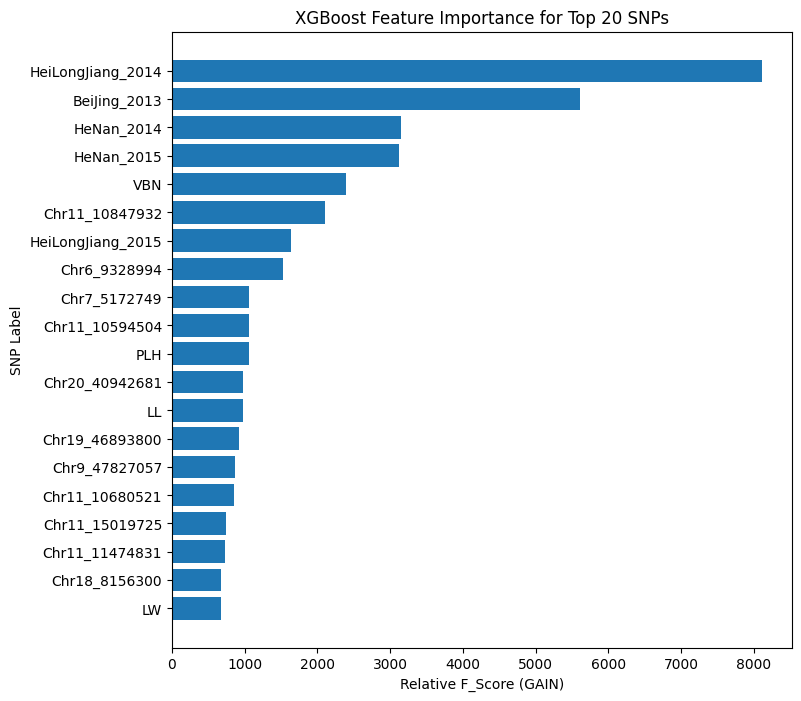

In [74]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_dupe, top_n=20)

In [75]:
explainer = shap.Explainer(best_xgbr_model)

In [76]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

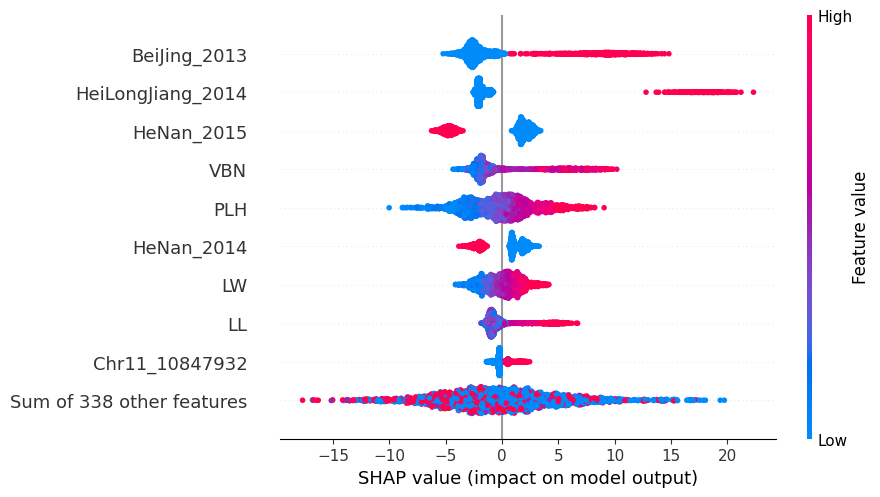

In [77]:
shap.plots.beeswarm(shap_values, show=False)

In [17]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [18]:
holdout_data = holdout_data.set_index('Line')

In [19]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [20]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [21]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [22]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [23]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 347 entries, Chr1_2475213 to landrace
dtypes: float64(4), int64(343)
memory usage: 1.6+ MB


In [24]:
y_holdout.shape

(613, 1)

In [25]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [26]:
#pickle.dump(best_xgbr_model, open("enet_allfeats_xgbr_md.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/enet_allfeats_xgbr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.74
RMSE of Holdout: 9.79
Mean of Holdout: 117.42
This is 8.34% of the mean pheno data
0 117.0 114.73535
1 148.0 144.57933
2 117.0 115.312675
3 121.0 121.678406
4 119.0 123.39072


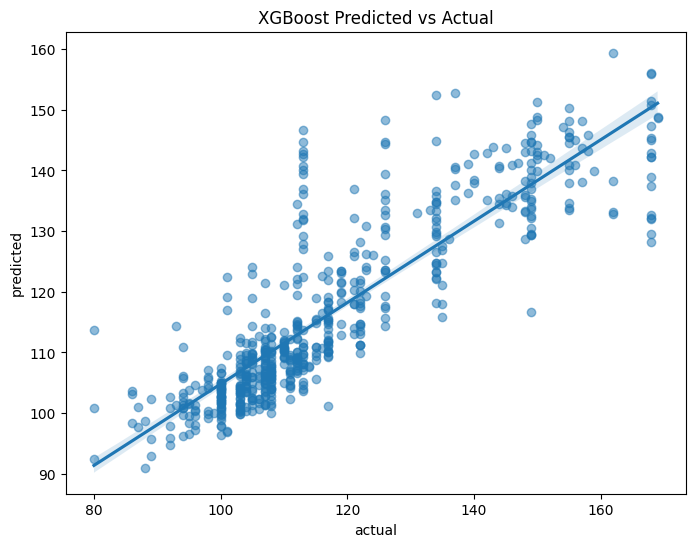

In [27]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [63]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 20), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 2), ('min_samples_split', 2), ('n_estimators', 265)])


In [64]:
best_rfr_model = eval_k_fold(best_rfreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.35084590096304846
RMSE for dataset is:10.996511337015729& mean of this fold is 115.06530612244897
this is 9.556756686775403% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6619279705252268
RMSE for dataset is:12.622166350607019& mean of this fold is 117.45918367346938
this is 10.74600210545989% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.46679478168113575
RMSE for dataset is:12.036597721458941& mean of this fold is 115.33877551020409
this is 10.43586397394522% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5397807343318208
RMSE for dataset is:12.03203687564427& mean of this fold is 115.82448979591837
this is 10.388163070560124% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.43933748392590033
RM

In [78]:
pickle.dump(best_rfr_model, open("enet_allfeats_rfr_md.pickle.dat", "wb"))

In [30]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/enet_allfeats_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.55
RMSE of Holdout: 12.93
Mean of Holdout: 117.42
This is 11.01% of the mean pheno data
0 117.0 116.43604821802943
1 148.0 134.27778526504943
2 117.0 117.14443437066078
3 121.0 126.87523687004811
4 119.0 127.63708922105148


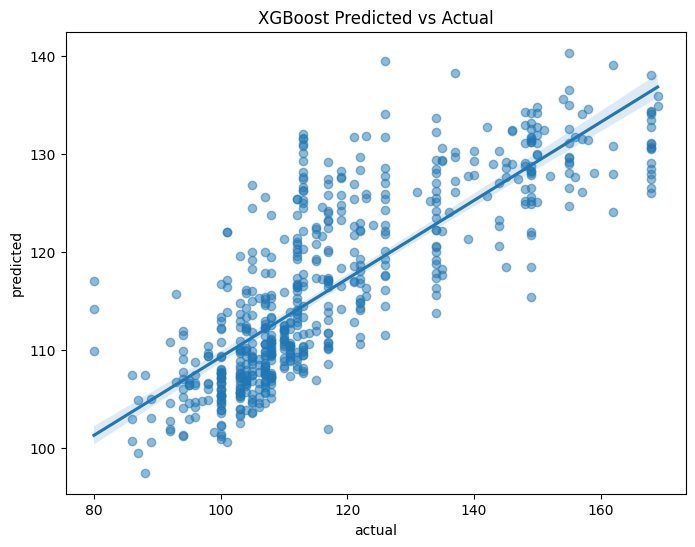

In [31]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [79]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/home/supadhyaya/.local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [80]:
best_svr_model = eval_k_fold(best_svreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.66582077809728
RMSE for dataset is:9.659766977183482& mean of this fold is 114.93061224489796
this is 8.404868632040461% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.652880948622484
RMSE for dataset is:9.866802041546428& mean of this fold is 115.00408163265305
this is 8.579523353843253% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6605272201754387
RMSE for dataset is:9.84221619514042& mean of this fold is 116.0734693877551
this is 8.479298712319443% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6359169355837183
RMSE for dataset is:9.844214672704071& mean of this fold is 114.9734693877551
this is 8.562161971040338% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7042922540745138
RMSE for dataset is:

In [82]:
pickle.dump(best_svr_model, open("enet_allfeats_svr_md.pickle.dat", "wb"))

In [28]:
best_svr_model = pickle.load(open("../pickle_bestmodels/enet_allfeats_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.68
RMSE of Holdout: 10.93
Mean of Holdout: 117.42
This is 9.31% of the mean pheno data
0 117.0 120.96223394805045
1 148.0 140.78812795664297
2 117.0 117.44112678812806
3 121.0 126.69914893056219
4 119.0 119.83408199249178


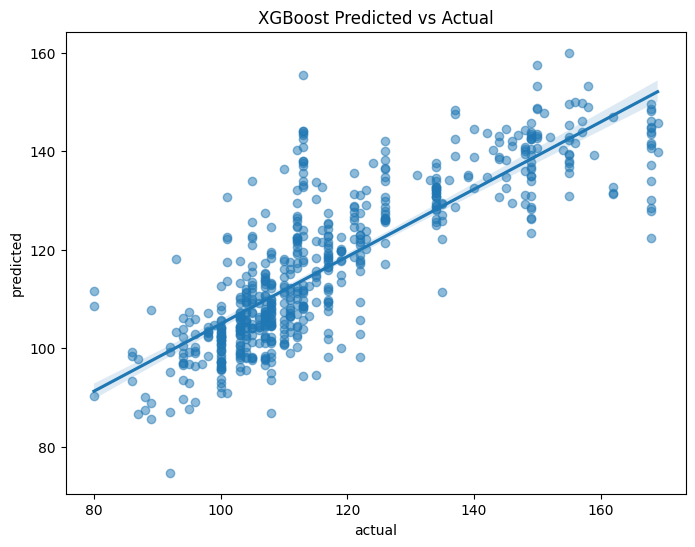

In [29]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only Location

In [32]:
snps_loc= fs_data.drop(['MD', 'LL', 'LW', 'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_50003028,Chr20_50084112,Chr20_51274009,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,1,0,0,0,0,0,1
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,0,0,1,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,0,1,0,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,0,0,1,0,0,0,1
s1019,0,0,0,0,0,0,0,1,0,0,...,2,2,0,0,0,1,0,0,0,1


In [33]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 343 entries, Chr1_2475213 to landrace
dtypes: int64(343)
memory usage: 6.4+ MB


In [34]:
snps_loc_dupe= fs_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
snps_loc_dupe.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_50003028,Chr20_50084112,Chr20_51274009,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,1,0,0,0,0,0,1
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,0,0,1,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,0,1,0,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,0,0,1,0,0,0,1
s1019,0,0,0,0,0,0,0,1,0,0,...,2,2,0,0,0,1,0,0,0,1


In [35]:
y_all = fs_data["MD"].values

In [36]:
# Split training set into training and validation

In [88]:
X_train, X_test, y_train, y_test = train_test_split(snps_loc, y_all, test_size=0.1, random_state=42)

In [89]:
X_train = X_train.to_numpy()
#y_train = y_train.to_numpy()

In [90]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.42572046360158744), ('colsample_bytree', 0.8914182279713662), ('gamma', 0.11701165905765691), ('learning_rate', 0.02786392096820084), ('max_delta_step', 12), ('max_depth', 33), ('min_child_weight', 4), ('n_estimators', 186), ('reg_alpha', 1.1738240567675757e-07), ('reg_lambda', 0.0665462520074097), ('subsample', 0.45765548465446443)])


In [91]:
snps_loc = snps_loc.to_numpy()
#y_all = y_all.to_numpy()
best_xgbr_model = eval_k_fold(best_xgbreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5305279614075197
RMSE for dataset is:10.435659951351257& mean of this fold is 116.00816326530612
this is 8.995625529804581% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6005120532154375
RMSE for dataset is:9.466536265209351& mean of this fold is 116.95918367346938
this is 8.093880247692518% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7437622703815373
RMSE for dataset is:7.794275847282339& mean of this fold is 116.68367346938776
this is 6.679834132345162% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.613520400628732
RMSE for dataset is:8.798228362221066& mean of this fold is 113.83673469387755
this is 7.728813010914884% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6126553225259282
RMSE for datas

In [37]:
#pickle.dump(best_xgbr_model, open("enet_onlyloc_xgbr_md.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/enet_onlyloc_xgbr_md.pickle.dat", "rb"))

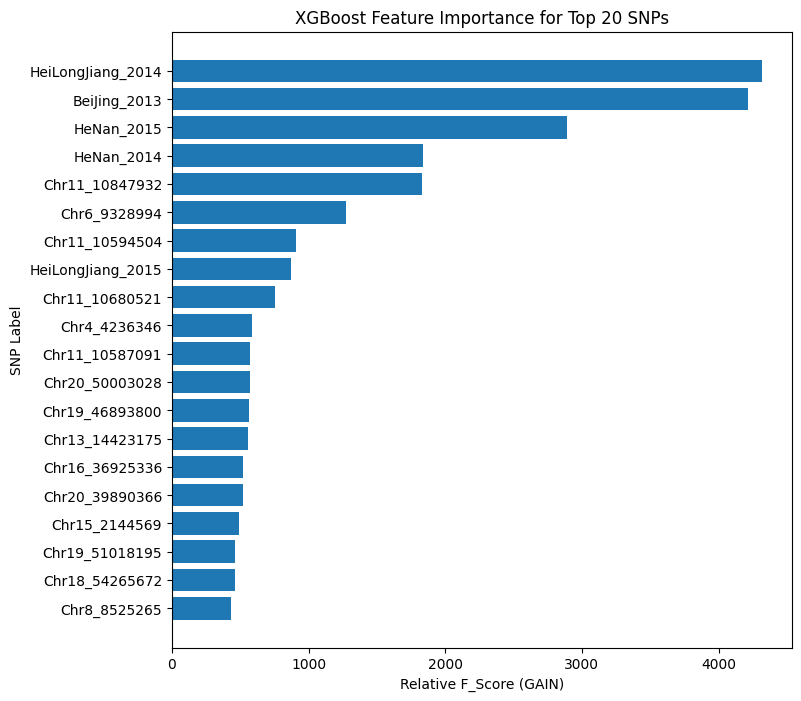

In [93]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, snps_loc_dupe, top_n=20)

In [94]:
explainer = shap.Explainer(best_xgbr_model)

In [95]:
shap_values = explainer(snps_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

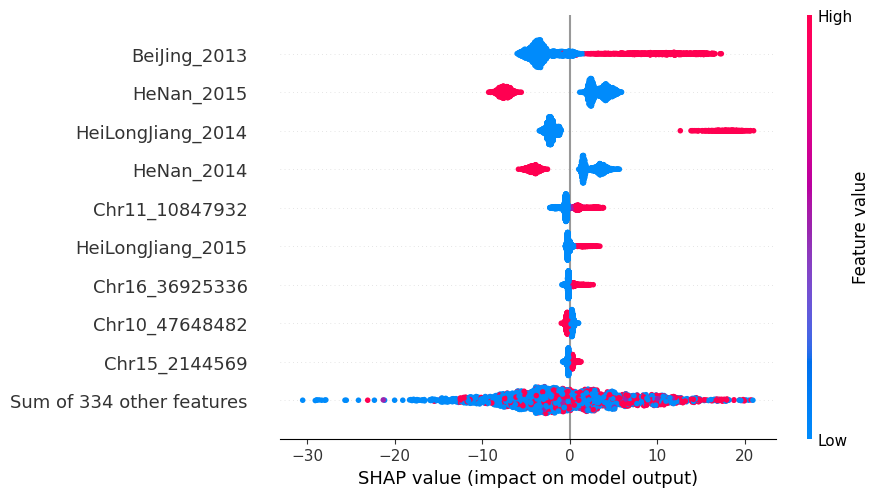

In [96]:
shap.plots.beeswarm(shap_values, show=False)

In [97]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [98]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [38]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [39]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [40]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [41]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 343 entries, Chr1_2475213 to landrace
dtypes: int64(343)
memory usage: 1.6+ MB


In [42]:
X_holdout.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_50003028,Chr20_50084112,Chr20_51274009,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,2,0,0,0,1,0,0,0,0,1
s1014,2,2,0,0,2,2,0,1,2,0,...,2,0,2,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,1,0,0,...,2,2,0,0,1,0,0,0,0,1
s101,0,2,0,2,2,0,0,0,0,2,...,0,0,2,1,0,0,0,0,0,1
s101,0,2,0,2,2,0,0,0,0,2,...,0,0,2,0,0,0,0,1,0,1


In [43]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.72
RMSE of Holdout: 10.32
Mean of Holdout: 117.42
This is 8.79% of the mean pheno data
0 117.0 112.62128
1 148.0 142.16957
2 117.0 118.15313
3 121.0 120.856285
4 119.0 120.62102


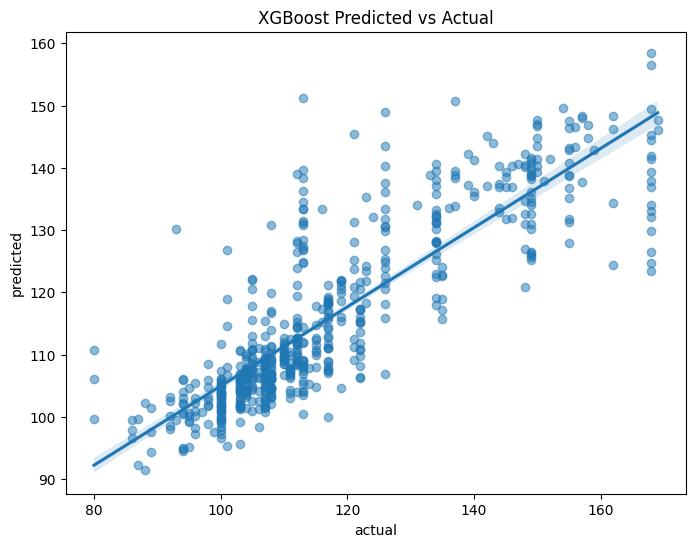

In [44]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [106]:
 # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 117.0 112.62128
1 148.0 142.16957
2 117.0 118.15313
3 121.0 120.856285
4 119.0 120.62102
5 94.0 102.0448


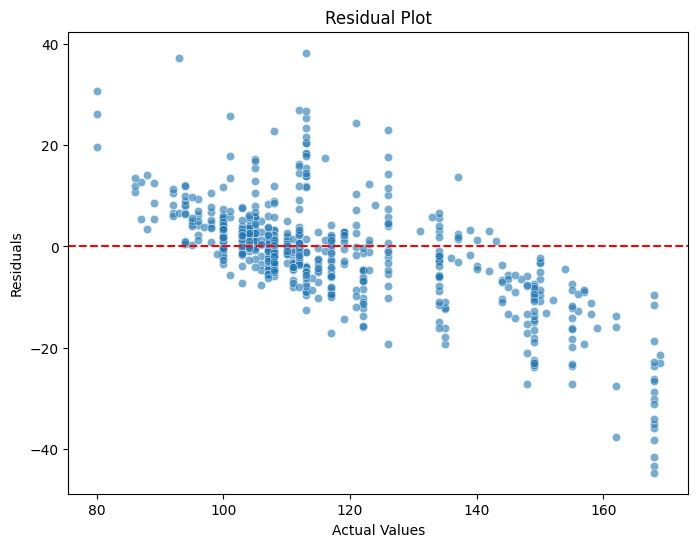

In [107]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [108]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 30), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [109]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.2176262585248252
RMSE for dataset is:13.713769627227304& mean of this fold is 117.19183673469388
this is 11.701983695565232% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.1901014114902462
RMSE for dataset is:13.291272898080422& mean of this fold is 116.2408163265306
this is 11.434256329329342% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.2632638041544118
RMSE for dataset is:13.121690845915486& mean of this fold is 114.58367346938776
this is 11.451623471838754% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.368313935860912
RMSE for dataset is:13.52324009718102& mean of this fold is 115.33265306122449
this is 11.725421845626139% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.0154060429636136
RMSE

In [110]:
pickle.dump(best_rfr_model, open("enet_onlyloc_rfr_md.pickle.dat", "wb"))

In [46]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/enet_onlyloc_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.44
RMSE of Holdout: 14.52
Mean of Holdout: 117.42
This is 12.37% of the mean pheno data
0 117.0 123.106
1 148.0 126.88
2 117.0 113.15
3 121.0 131.552
4 119.0 130.922


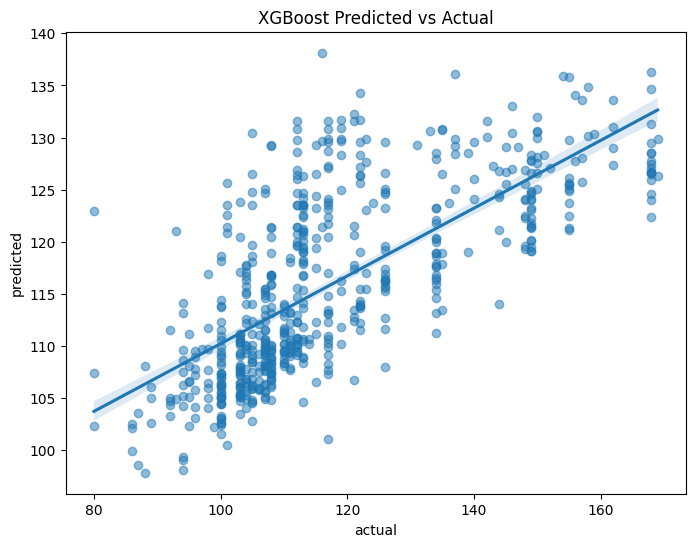

In [47]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [112]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [113]:
best_svr_model = eval_k_fold(best_svreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6245292815610306
RMSE for dataset is:9.603108074798655& mean of this fold is 115.26530612244898
this is 8.33130835101158% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7083639751392925
RMSE for dataset is:8.777565270631282& mean of this fold is 115.46122448979592
this is 7.602175803537416% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.585947348144094
RMSE for dataset is:10.476750619305221& mean of this fold is 116.93877551020408
this is 8.95917592226799% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6394685700004783
RMSE for dataset is:10.392383622207221& mean of this fold is 116.08367346938776
this is 8.952493758691897% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.49230175342691207
RMSE for datas

In [114]:
pickle.dump(best_svr_model, open("enet_onlyloc_svr_md.pickle.dat", "wb"))

In [48]:
best_svr_model = pickle.load(open("../pickle_bestmodels/enet_onlyloc_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.62
RMSE of Holdout: 11.89
Mean of Holdout: 117.42
This is 10.13% of the mean pheno data
0 117.0 116.4997586530036
1 148.0 133.83527345357226
2 117.0 113.17521961854834
3 121.0 134.695433855584
4 119.0 127.69569976693714


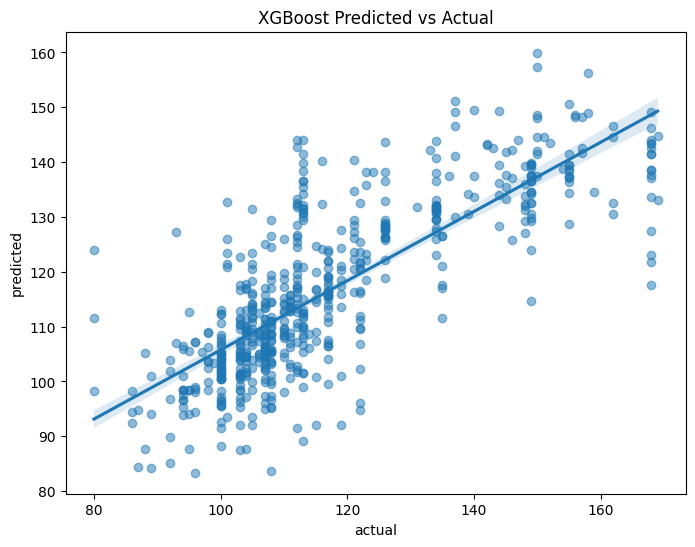

In [49]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only snps

In [14]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 348 entries, Chr1_2475213 to MD
dtypes: float64(5), int64(343)
memory usage: 6.5+ MB


In [15]:
only_snps = fs_data.iloc[:, 0:336]
only_snps.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_39258975,Chr20_39890366,Chr20_40195415,Chr20_40942681,Chr20_43468889,Chr20_43870603,Chr20_48582557,Chr20_50003028,Chr20_50084112,Chr20_51274009
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s100,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s1014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1019,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,2,2,0,2,2,0


In [16]:
only_snps_dupe = fs_data.iloc[:, 0:336]
only_snps.head()

,Chr1_2475213,Chr1_2645491,Chr1_15775291,Chr1_16121722,Chr1_50820261,Chr1_51525075,Chr1_53630801,Chr1_54026007,Chr1_56403929,Chr1_56955989,...,Chr20_39258975,Chr20_39890366,Chr20_40195415,Chr20_40942681,Chr20_43468889,Chr20_43870603,Chr20_48582557,Chr20_50003028,Chr20_50084112,Chr20_51274009
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s100,0,0,1,2,1,0,0,2,2,0,...,0,0,0,0,0,0,0,2,0,0
s1014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1014,2,2,0,0,2,2,0,1,2,0,...,0,0,0,0,2,2,0,2,0,2
s1019,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,2,2,0,2,2,0


In [17]:
y_all = fs_data["MD"]
y_all.head()

Line
s100     155.0
s100     115.0
s1014    108.0
s1014    104.0
s1019    113.0
Name: MD, dtype: float64

### Run models

In [124]:
X_train, X_test, y_train, y_test = train_test_split(only_snps, y_all, test_size=0.1, random_state=42)

In [125]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [126]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6841569429227226), ('colsample_bytree', 0.01), ('gamma', 0.00026100596174537374), ('learning_rate', 0.2758432307197503), ('max_delta_step', 16), ('max_depth', 32), ('min_child_weight', 6), ('n_estimators', 91), ('reg_alpha', 0.637505352458757), ('reg_lambda', 52.823886415964516), ('subsample', 0.1997577624506902)])


In [127]:
only_snps = only_snps.to_numpy()
y_all = y_all.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.361640002203631
RMSE for dataset is:17.598195401881732& mean of this fold is 114.9469387755102
this is 15.309842601594434% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.344998290400985
RMSE for dataset is:17.703183262983323& mean of this fold is 115.05714285714286
this is 15.386426973042372% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.146922522993773
RMSE for dataset is:17.771662426326312& mean of this fold is 116.43469387755103
this is 15.263201915587072% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.639989320982718
RMSE for dataset is:17.784608536863043& mean of this fold is 116.78775510204082
this is 15.228144869574828% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.347341695706201
RMSE fo

In [128]:
pickle.dump(best_xgbr_model, open("enet_onlysnps_xgbr_md.pickle.dat", "wb"))

In [18]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/enet_onlysnps_xgbr_md.pickle.dat", "rb"))

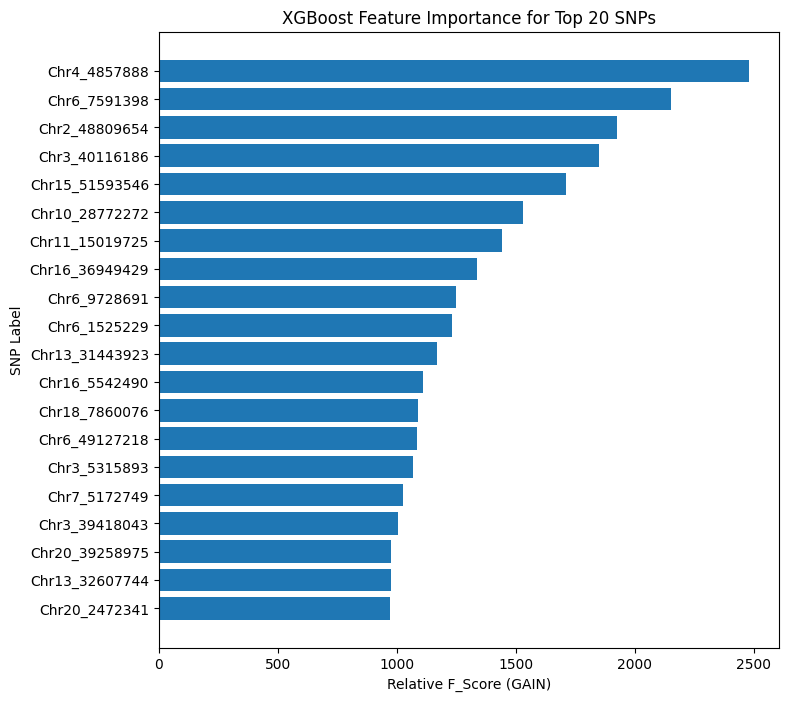

In [129]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, only_snps_dupe , top_n=20)

In [130]:
explainer = shap.Explainer(best_xgbr_model)

In [131]:
shap_values = explainer(only_snps_dupe)

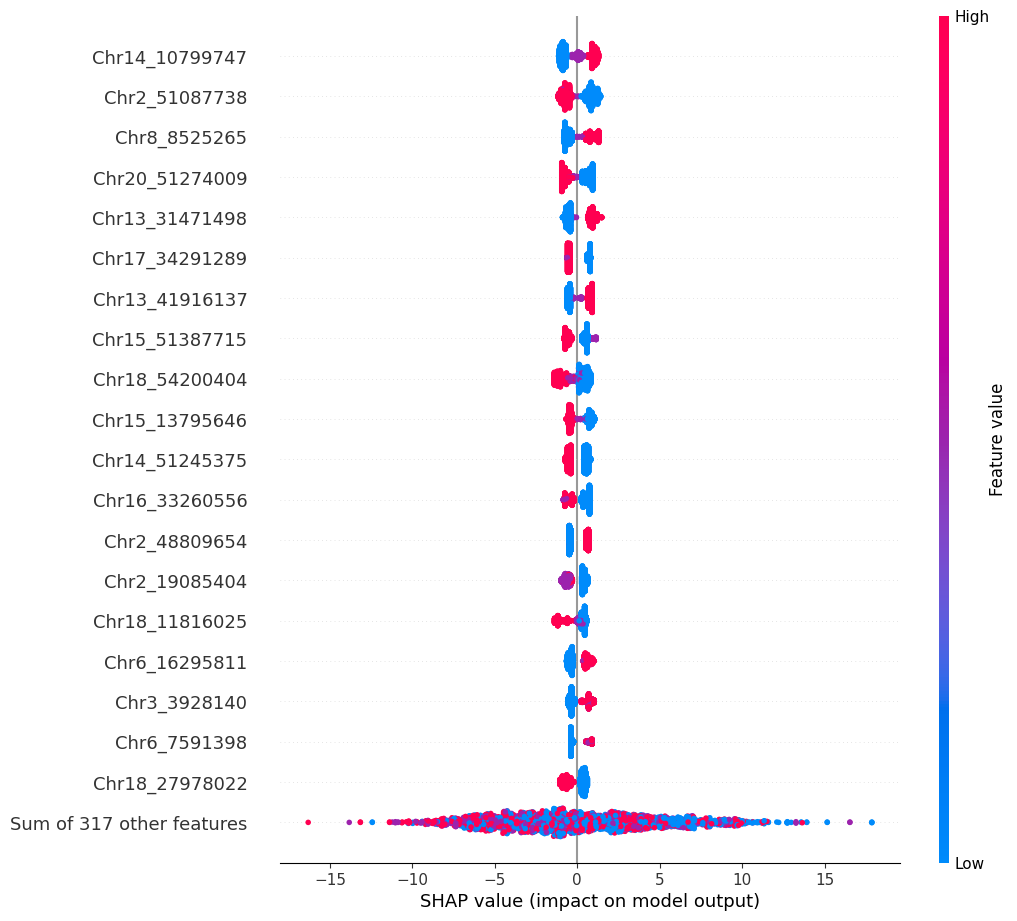

In [132]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])

In [19]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [20]:
holdout_data = holdout_data.set_index('Line')

In [21]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [22]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [23]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [24]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 336 entries, Chr1_2475213 to Chr20_51274009
dtypes: int64(336)
memory usage: 1.6+ MB


In [25]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -0.01
RMSE of Holdout: 19.44
Mean of Holdout: 117.42
This is 16.56% of the mean pheno data
0 117.0 124.25077
1 148.0 113.5715
2 117.0 110.09629
3 121.0 124.44577
4 119.0 124.44577


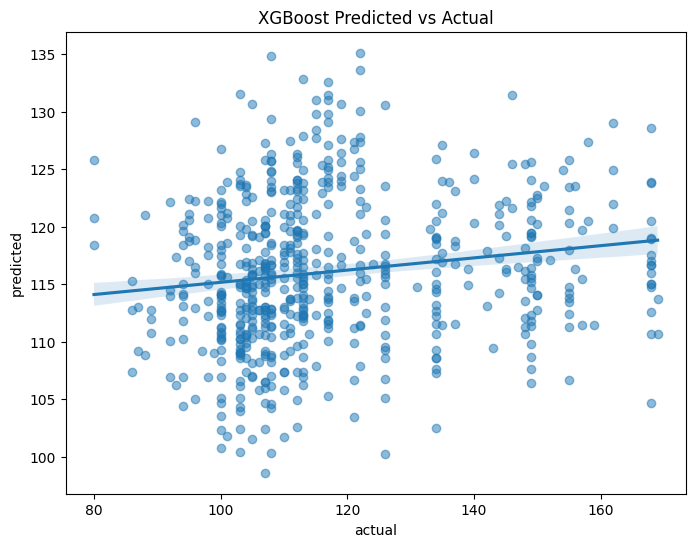

In [26]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [141]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 25), ('max_features', 'sqrt'), ('max_samples', 0.583387025372712), ('min_samples_leaf', 10), ('min_samples_split', 15), ('n_estimators', 327)])


In [142]:
best_rfr_model = eval_k_fold(best_rfreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -17.001085677694668
RMSE for dataset is:19.015931982107695& mean of this fold is 116.79591836734694
this is 16.28133264237772% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -13.658089710081855
RMSE for dataset is:18.13250875074985& mean of this fold is 115.68571428571428
this is 15.673939399265121% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -19.361230047884852
RMSE for dataset is:19.08361294087321& mean of this fold is 116.57551020408164
this is 16.370173210020432% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -14.324654582338388
RMSE for dataset is:18.526802963814063& mean of this fold is 116.78775510204082
this is 15.863651927915443% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -11.27865301151378
RMSE 

In [143]:
pickle.dump(best_rfr_model, open("enet_onlysnps_rfr_md.pickle.dat", "wb"))

In [29]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/enet_onlysnps_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.03
RMSE of Holdout: 18.99
Mean of Holdout: 117.42
This is 16.17% of the mean pheno data
0 117.0 119.48812967571347
1 148.0 111.38669032640802
2 117.0 112.22793469088062
3 121.0 123.56330105527083
4 119.0 123.56330105527083


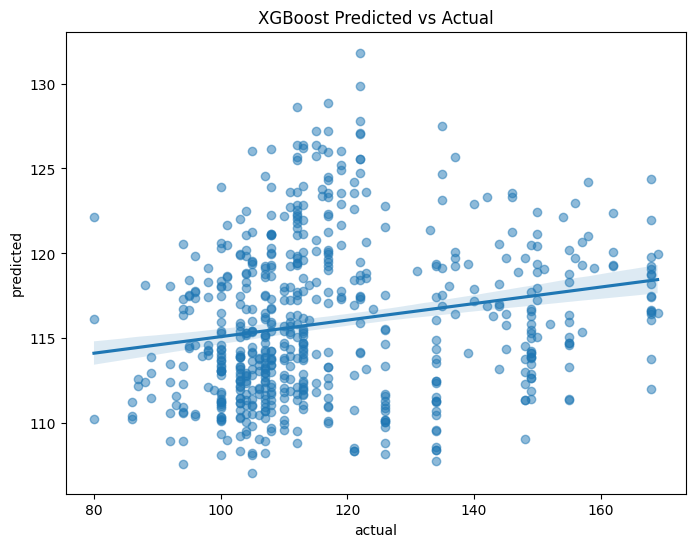

In [30]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [145]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'sigmoid')])


In [146]:
best_svr_model = eval_k_fold(best_svreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -20.17663320545754
RMSE for dataset is:18.92509533456076& mean of this fold is 116.41632653061224
this is 16.25639280894533% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -19.380641370432254
RMSE for dataset is:18.736895098326773& mean of this fold is 117.89795918367346
this is 15.892467713657815% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -18.635728660542913
RMSE for dataset is:17.86127031251859& mean of this fold is 115.48163265306123
this is 15.46676289742005% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -22.11812269432817
RMSE for dataset is:18.06283420299492& mean of this fold is 115.23673469387755
this is 15.674545318364169% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -16.125484573237067
RMSE for

In [147]:
pickle.dump(best_svr_model, open("enet_onlysnps_svr_md.pickle.dat", "wb"))

In [27]:
best_svr_model = pickle.load(open("../pickle_bestmodels/enet_onlysnps_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: -0.07
RMSE of Holdout: 20.03
Mean of Holdout: 117.42
This is 17.06% of the mean pheno data
0 117.0 111.36710754183295
1 148.0 108.04051462671329
2 117.0 108.43758370313991
3 121.0 116.26668789718018
4 119.0 116.26668789718018


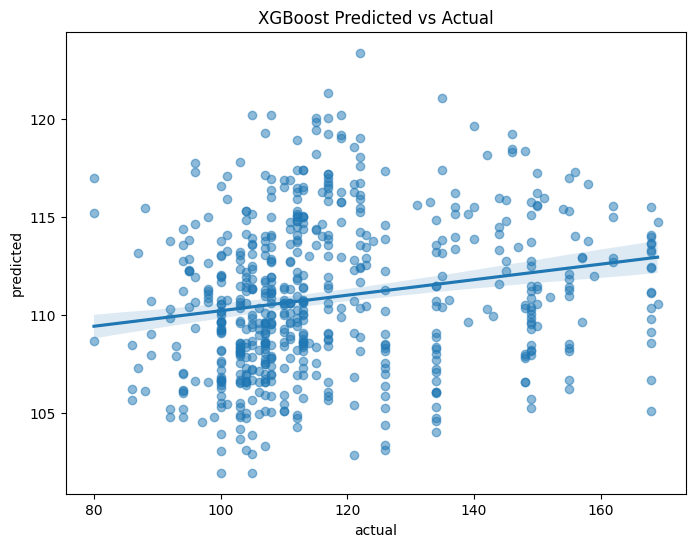

In [28]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)